## 1.Class Design: Node (Weekly/Daily) Demand Class - Chain Structure

In [1]:
class Node:
  def __init__(self,num,is_max=False,forecast=None,trend=None):
    self.num = num
    self.forecast = forecast
    self.trend = trend
    self.is_max = is_max
    self.trueval = None

    self.ss_idx = None

    if num == 1:
      self.previous = None
    else:
      self.previous = Node(self.num-1)
      self.previous.next = self

    if is_max:
      self.next = None

  def __repr__(self):
    return f'Node {self.num}'

  def get_num(self):
    return self.num

  def get_trueval(self):
    return self.trueval

  def get_forecast(self):
    if self.forecast is not None:
      return self.forecast
    else:
      print('Not forecated yet.')
      return None

  def get_trend(self):
    if self.trend is not None:
      return self.trend
    else:
      print('Not forecated yet.')
      return None

  def get_ss_idx(self):
    return self.ss_idx

  def set_forecast(self,forecast):
    self.forecast = forecast

  def set_trend(self,trend):
    self.trend = trend

  def set_trueval(self,trueval):
    self.trueval = trueval

  def set_ss_idx(self,ss_idx):
    self.ss_idx = ss_idx




In [2]:
class Demand_list:
  def __init__(self,latest_node_num,*args):
    self.latest_node = Node(latest_node_num,is_max=True)
    self.set_nodelist()
    if args != ():
      self.seasonality_index = args[0]
    self.set_seasonality_index()

  def __getitem__(self,idx):
    return self.node_list[idx]

  def __repr__(self):
    return f'{self.get_nodelist()}'

  def set_nodelist(self):
    node_list = []
    node = self.latest_node
    while node is not None:
      node_list.append(node)
      node = node.previous
    node_list.reverse()
    self.node_list = node_list
    return self.node_list

  def get_nodelist(self):
    node_list_repr = []
    for node in self.node_list:
      node_list_repr.append(node)
    return node_list_repr

  def get_forecast(self,idx):
    return self.node_list[idx].get_forecast()

  def get_trend(self,idx):
    return self.node_list[idx].get_trend()

  def get_ss_idx(self,idx):
    return self.node_list[idx].get_ss_idx()

  def set_seasonality_index(self):
    for node in self.node_list:
      idx = node.get_num() % len(self.seasonality_index) - 1
      node.set_ss_idx(self.seasonality_index[idx])




## 2.Class Design: Demand Forecast Methods - w/o Seasonality Index

In [3]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 18.3 MB/s eta 0:00:00


In [4]:
from pandas import DataFrame
import gurobipy as gp
from gurobipy import GRB
params = {
"WLSACCESSID": '3f8a3d38-3768-45b8-bb4d-46826f47f5d1',
"WLSSECRET": 'a5686db7-20a3-4b62-b5a5-e69a78d2395e',
"LICENSEID": 2636077,
}
env = gp.Env(params=params)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2636077
Academic license 2636077 - for non-commercial use only - registered to ya___@u.nus.edu


In [22]:
class DemandForecast:
  def __init__(self,demand_data,with_ss_idx=False,print_iteration=False,*args):
    self.true_demand_data = demand_data
    # self.demand_data is deseasonalized
    self.demand_data = demand_data
    self.with_ss_idx = with_ss_idx
    self.nodelist = Demand_list(len(demand_data),args[0])
    self.reset()

    self.set_trueval()
    if with_ss_idx:
      self.set_dess_demand_data()

    self.print_iteration = print_iteration

    # self.MAE = self.get_MAE()

  def __repr__(self):
    return f'Demand Forecast: seasonal index considered = {self.with_ss_idx}, Whether to print iterations = {self.print_iteration}.'

  def reset(self):
    self.nodelist[0].set_forecast(demand_data[0])
    self.nodelist[0].set_trend(0)

  def set_trueval(self):
    for idx, node in enumerate(self.nodelist):
      node.set_trueval(self.true_demand_data[idx])

  def set_dess_demand_data(self):
    dess_demand_data = []
    for node in self.nodelist:
      dess_demand_data.append(node.trueval/node.ss_idx)
    self.demand_data = dess_demand_data

  def SimpleMovingAverage(self,n):
    self.reset()
    forecast_list = []
    for idx, node in enumerate(self.nodelist):
      if idx < n:
        forecast_list.append(node.trueval)
      else:
        forecast = sum(self.demand_data[idx-n:idx])/n
        forecast_list.append(forecast)
    if self.with_ss_idx:
      ress_forecast_list = []
      for node, forecast in zip(self.nodelist,forecast_list):
        ress_forecast = forecast * node.ss_idx
        node.set_forecast(ress_forecast)
        ress_forecast_list.append(ress_forecast)
      forecast_list = ress_forecast_list
    self.forecast_list = forecast_list

  def WeightedMovingAverage(self,n):
    self.reset()
    model = gp.Model('Weight_Opimization',env=env)
    w = model.addVars(n,vtype=GRB.CONTINUOUS,name='w')

    quad_expr = gp.QuadExpr()
    for idx, node in enumerate(self.nodelist):
      if idx < n:
        continue
      else:
        used_data = self.demand_data[idx-n:idx]
        # lin_expr = gp.LinExpr()
        lin_expr = gp.quicksum(w[i] * used_data[i] for i in range(n))
        quad_expr += (lin_expr - self.demand_data[idx])**2
    obj = quad_expr
    model.setObjective(obj,GRB.MINIMIZE)
    model.addConstr(gp.quicksum(w[i] for i in range(n)) == 1)
    model.setParam('OutputFlag', 0)
    model.optimize()

    if model.status == GRB.OPTIMAL:
      self.weights = [w[i].X for i in range(n)]
      forecast_list = []
      for idx, node in enumerate(self.nodelist):
        if idx < n:
          forecast_list.append(node.trueval)
        else:
          used_data = self.demand_data[idx-n:idx]
          forecast = sum([w[i].X * used_data[i] for i in range(n)])
          node.set_forecast(forecast)
          forecast_list.append(forecast)
      if self.with_ss_idx:
        ress_forecast_list = []
        for node, forecast in zip(self.nodelist,forecast_list):
          ress_forecast = forecast * node.ss_idx
          node.set_forecast(ress_forecast)
          ress_forecast_list.append(ress_forecast)
        forecast_list = ress_forecast_list
      self.forecast_list = forecast_list
    else:
      print('No solution found')

  def ExponentialSmoothing(self,alpha):
    self.reset()
    self.alpha = alpha
    forecast_list = []
    for idx, node in enumerate(self.nodelist):
      if idx == 0:
        forecast_list.append(node.forecast)
      else:
        previous = node.previous
        forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast
        node.set_forecast(forecast)
        forecast_list.append(forecast)
    if self.with_ss_idx:
      ress_forecast_list = []
      for node, forecast in zip(self.nodelist,forecast_list):
        ress_forecast = forecast * node.ss_idx
        node.set_forecast(ress_forecast)
        ress_forecast_list.append(ress_forecast)
      forecast_list = ress_forecast_list
    self.forecast_list = forecast_list

  def DoubleExponentialSmoothing(self,alpha,beta):
    self.reset()
    self.alpha = alpha
    self.beta = beta
    forecast_list = []
    trend_list = []
    if self.print_iteration:
      for idx, node in enumerate(self.nodelist):
        # print(idx)
        if idx == 0:
          forecast_list.append(node.forecast)
          trend_list.append(node.trend)
        else:
          previous = node.previous
          forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
          trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          print(f"Node {idx+1} Forecast: {forecast}, trend: {trend}.")
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))
    else:
      for idx, node in enumerate(self.nodelist):
        # print(idx)
        if idx == 0:
          forecast_list.append(node.forecast)
          trend_list.append(node.trend)
        else:
          previous = node.previous
          forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
          trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))
    if self.with_ss_idx:
      ress_forecast_list = []
      for node, forecast in zip(self.nodelist,forecast_list):
        ress_forecast = forecast * node.ss_idx
        node.set_forecast(ress_forecast)
        ress_forecast_list.append(ress_forecast)
      forecast_list = ress_forecast_list

    self.forecast_list = forecast_list
    self.trend_list = trend_list

  def MultiStepDoubleExponentialSmoothing(self,alpha,beta,step,train_ratio):
    self.reset()
    self.alpha = alpha
    self.beta = beta
    forecast_list = []
    trend_list = []
    train_len = round(len(self.true_demand_data) * train_ratio)
    if self.print_iteration:
      for idx, node in enumerate(self.nodelist):
        # print(idx)
        if idx == 0:
          forecast_list.append(node.forecast)
          trend_list.append(node.trend)
        elif idx < train_len:
          previous = node.previous
          forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
          trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          print(f"Node {idx+1} Forecast: {forecast}, trend: {trend}.")
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))
        else:
          previous = node.previous
          if (idx - train_len) % step == 0:
            forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
            trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          else:
            forecast = self.alpha * forecast_list[-1] + (1-self.alpha) * previous.forecast + previous.trend
            trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          print(f"Node {idx+1} Forecast: {forecast}, trend: {trend}.")
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))
    else:
      for idx, node in enumerate(self.nodelist):
        # print(idx)
        if idx == 0:
          forecast_list.append(node.forecast)
          trend_list.append(node.trend)
        elif idx < train_len:
          previous = node.previous
          forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
          trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))
        else:
          previous = node.previous
          if (idx - train_len) % step == 0:
            forecast = self.alpha * self.demand_data[idx-1] + (1-self.alpha) * previous.forecast + previous.trend
            trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          else:
            forecast = self.alpha * forecast_list[-1] + (1-self.alpha) * previous.forecast + previous.trend
            trend = self.beta * (forecast - previous.forecast) + (1-self.beta) * previous.trend
          node.set_forecast(forecast)
          node.set_trend(trend)

          forecast_list.append(forecast)
          trend_list.append(round(trend,2))

    if self.with_ss_idx:
      ress_forecast_list = []
      for node, forecast in zip(self.nodelist,forecast_list):
        ress_forecast = forecast * node.ss_idx
        node.set_forecast(ress_forecast)
        ress_forecast_list.append(ress_forecast)
      forecast_list = ress_forecast_list

    self.forecast_list = forecast_list
    self.trend_list = trend_list

  def get_MAE(self,forecast_len):
    AE_sum = 0
    for idx, node in enumerate(self.nodelist):
      if idx < len(self.true_demand_data)-forecast_len:
        continue
      AE_sum += abs(node.trueval - node.forecast)
    return AE_sum/forecast_len

  def get_MSE(self,forecast_len):
    SE_sum = 0
    for idx, node in enumerate(self.nodelist):
      if idx < len(self.true_demand_data)-forecast_len:
        continue
      SE_sum += (node.trueval - node.forecast)**2
    return SE_sum/forecast_len

  def get_MAPE(self,forecast_len):
    APE_sum = 0
    for idx, node in enumerate(self.nodelist):
      if idx < len(self.true_demand_data)-forecast_len:
        continue
      APE_sum += abs((node.trueval - node.forecast)/node.trueval)
    return APE_sum/forecast_len

  def get_result(self):
    result = {
      'Demand':self.true_demand_data,
      'Forecast':self.forecast_list,
    }
    self.result = result
    return result

  def result_df(self):
    self.result = self.get_result()
    result_df = DataFrame(self.result)
    return result_df




## Example: Implementation on Weekly Data (HW2)

In [ ]:
demand_data = [586,666,472,714,515,727,622,670,518,746,568,721]
Forecast = DemandForecast(demand_data,True,False,[0.9,1.1])
Forecast

Demand Forecast: seasonal index considered = True, Whether to print iterations = False.

In [ ]:
# Forecast.WeightedMovingAverage(3)
# Forecast.SimpleMovingAverage(3)
# Forecast.ExponentialSmoothing(0.5)
Forecast.DoubleExponentialSmoothing(0.2,0.1)
print(f'\nTrue demand: {Forecast.true_demand_data}.')
print(f'Forecast results: {Forecast.forecast_list}.')
print(f'\nMean Absolute Error: {Forecast.get_MAE(11):.4f}.')
print(f'Mean Squared Error: {Forecast.get_MSE(11):.4f}.')
print(f'Mean Absolute Percentage Error: {Forecast.get_MAPE(11):.4f}.')
Forecast.result_df()


True demand: [586, 666, 472, 714, 515, 727, 622, 670, 518, 746, 568, 721].
Forecast results: [527.4, 658.9244444444445, 541.4498181818182, 646.3693333333335, 539.8132581818184, 654.9352035555559, 548.1577008000002, 690.084519288889, 564.4933410240001, 682.0382666581335, 570.4045439841166, 700.1830625498313].

Mean Absolute Error: 42.6034.
Mean Squared Error: 2527.6558.
Mean Absolute Percentage Error: 0.0688.


,Demand,Forecast
0,586,527.400000
1,666,658.924444
2,472,541.449818
3,714,646.369333
4,515,539.813258
5,727,654.935204
6,622,548.157701
7,670,690.084519
8,518,564.493341
9,746,682.038267


In [ ]:
Forecast.nodelist

[Node 1, Node 2, Node 3, Node 4, Node 5, Node 6, Node 7, Node 8, Node 9, Node 10, Node 11, Node 12]

## 3.IO Data (Project)

In [7]:
from google.colab import files
_ = files.upload()

Saving Demand data.csv to Demand data.csv


In [10]:
import os
print(f'Current working directory: {os.getcwd()}')
print(f'Files in current working directory: \n{os.listdir()}')

Current working directory: /content
Files in current working directory: 
['.config', 'drive', 'Demand data.csv', 'Demand data.xlsx', 'sample_data']


In [8]:
import pandas as pd
class DemandData:
  DIRECTORY: str = ''
  def __init__(self,file_name):
    self.file_name = file_name
    self.dataset = pd.read_csv(os.path.join(self.DIRECTORY,self.file_name))

    self.day = self.dataset['Day'].to_numpy()
    self.demand_data = self.dataset['Demand'].to_numpy()
    self.convert_to_time_series()

  def get_data(self):
    return self.demand_data

  def get_day(self):
    return self.day

  def get_dataset(self):
    return self.dataset

  def convert_to_time_series(self):
    date_range = pd.date_range(start='2022-01-01', periods=len(self.day), freq='D')
    self.dataset['Day'] = date_range
    self.dataset.set_index('Day', inplace=True)

In [23]:
Demand = DemandData('Demand data.csv')
demand_data = Demand.get_data()
day = Demand.get_day()
dataset = Demand.get_dataset()

In [24]:
dataset

,Demand
Day,
2022-01-01,501
2022-01-02,397
2022-01-03,565
2022-01-04,353
2022-01-05,439
...,...
2024-09-22,916
2024-09-23,943
2024-09-24,1014


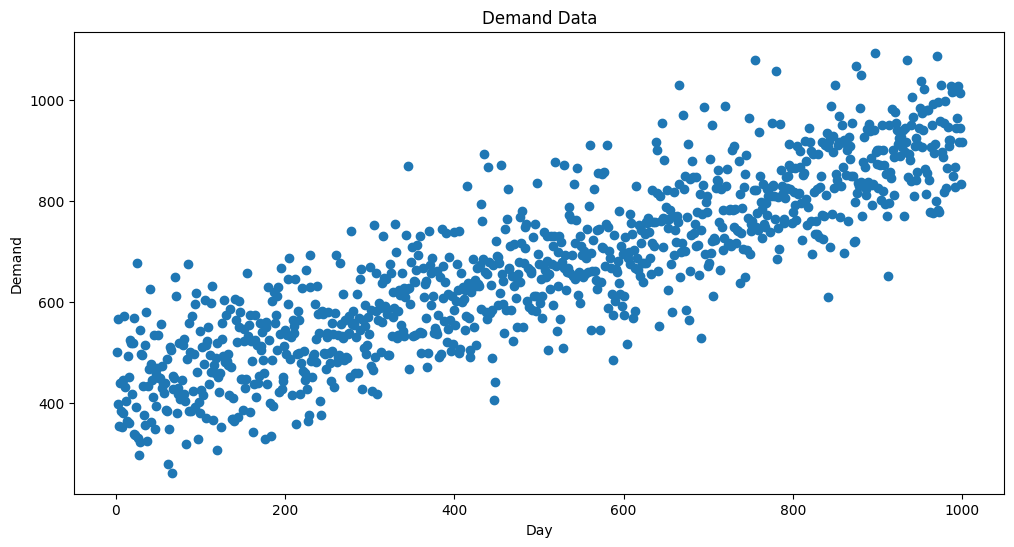

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.scatter(day,demand_data)
plt.xlabel('Day')
plt.ylabel('Demand')
plt.title('Demand Data')
plt.savefig('Demand_scatter.png')
plt.show()

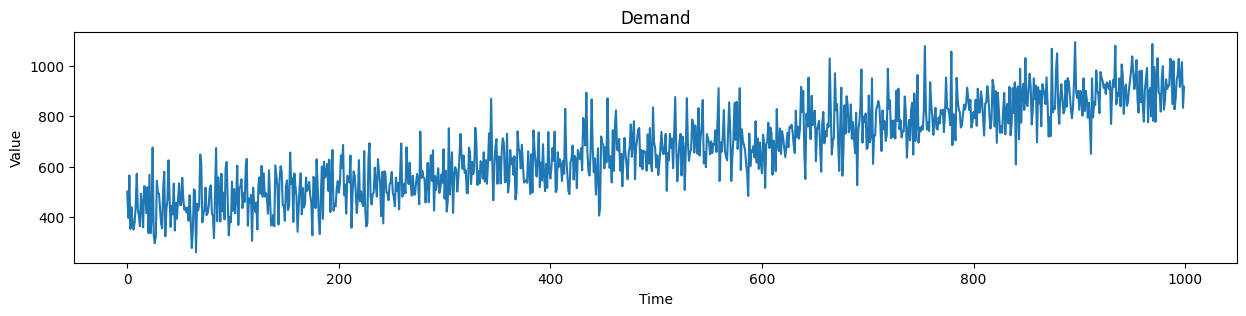

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(demand_data, label='Demand')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Demand')
plt.savefig('Demand_line.png')
plt.show()

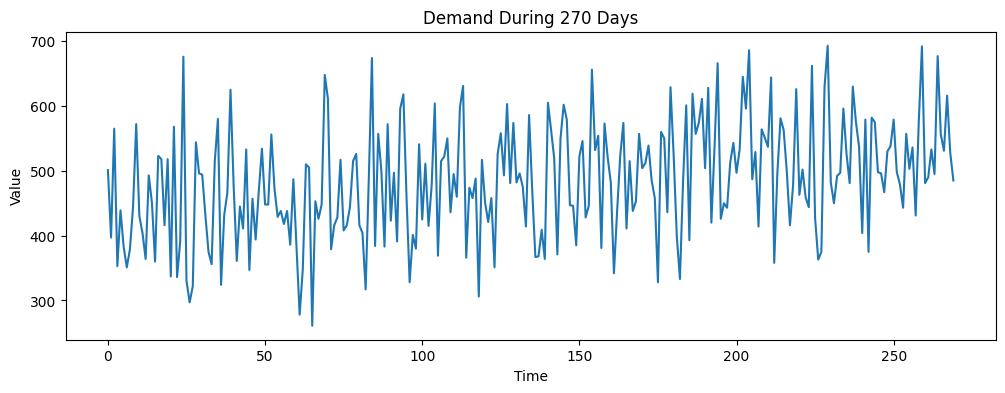

In [ ]:
period_obs = 270
plt.figure(figsize=(12,4))
plt.plot(demand_data[:period_obs], label='Demand')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Demand During {period_obs} Days')
plt.savefig(f'Demand_line_{period_obs}.png')
plt.show()

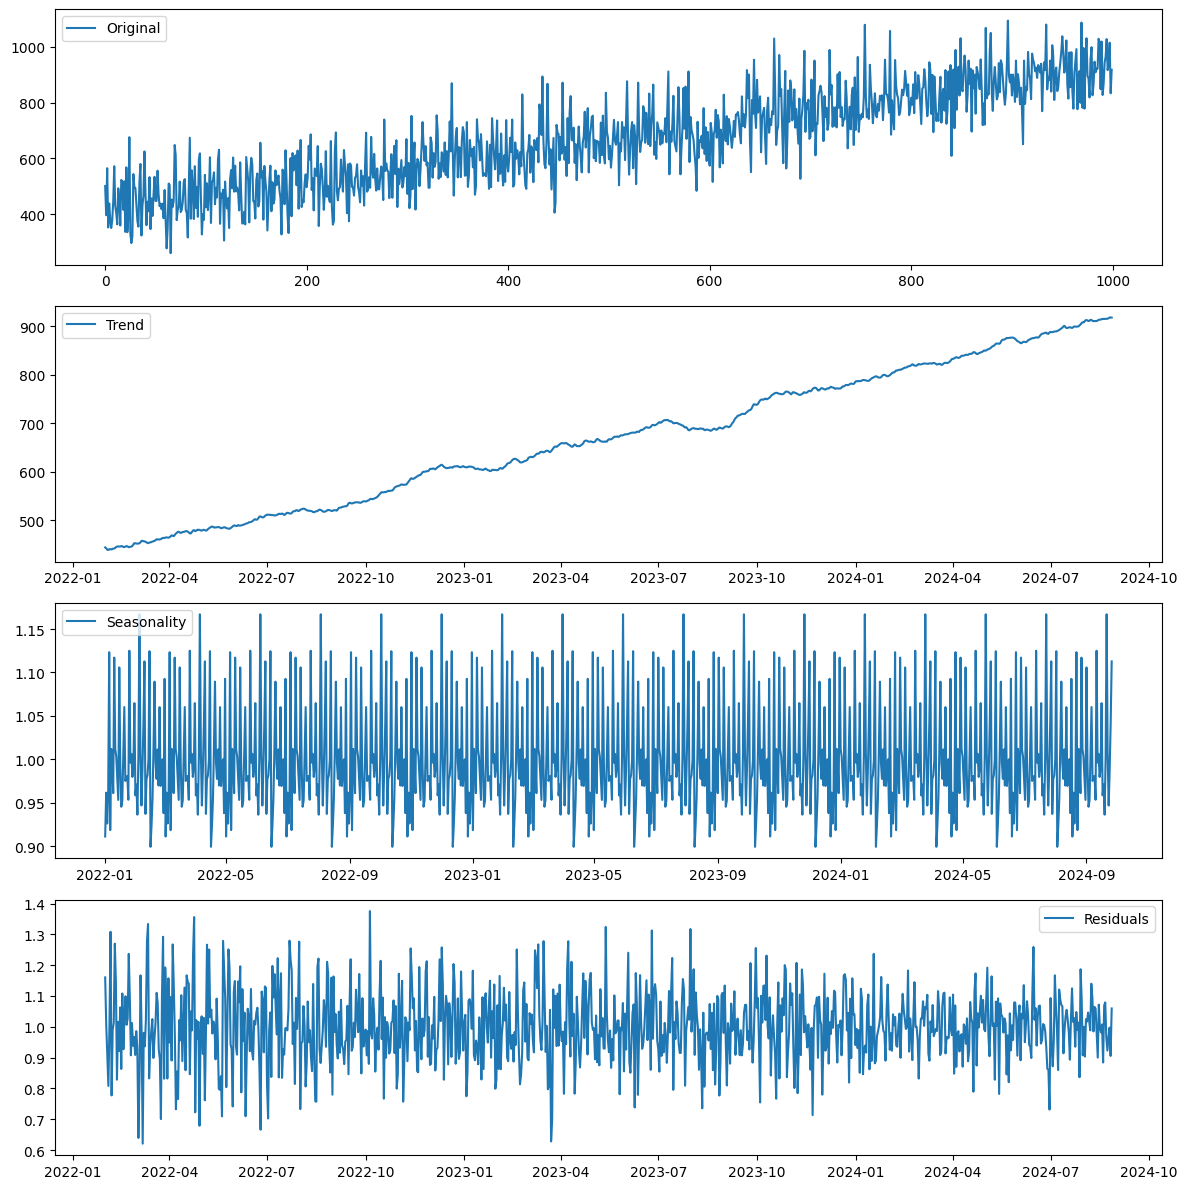

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
period = 60
decomposition = seasonal_decompose(dataset,model='multiplicative',period=period)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

fig, ax = plt.subplots(4,1,figsize=(12,12))
plt.subplot(411)
plt.plot(demand_data, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Decomposition.png')
plt.show()

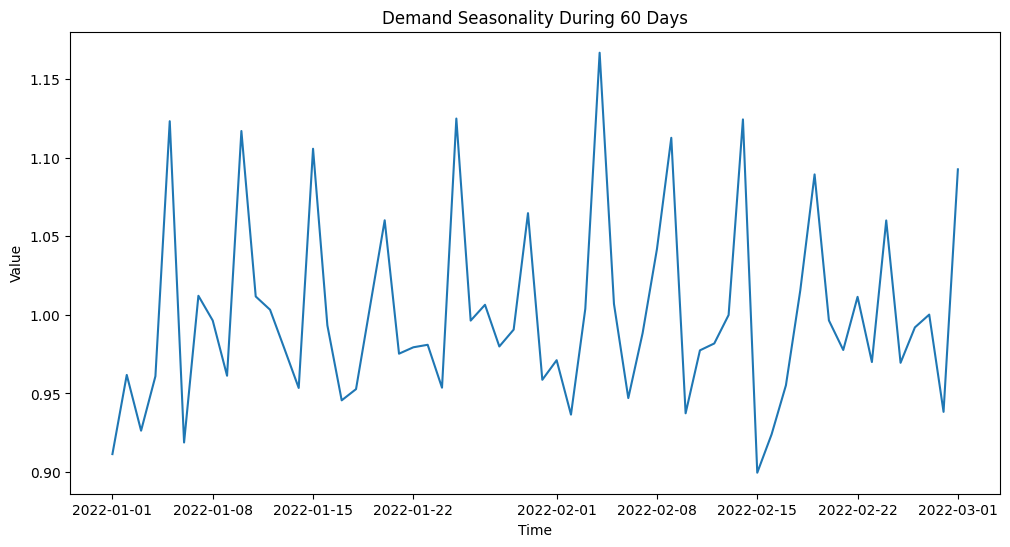

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(seasonal[:period], label='Demand Seasonality')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Demand Seasonality During {period} Days')
plt.savefig(f'Seasonality_line_{period}.png')
plt.show()

Seasonality: level = 60 days

**Warning: seasonal decomposition derives inconsistent seasonality index with manually computation results**

In [16]:
period = 60
overall_avg=sum(demand_data)/len(demand_data)
seasonality_index=[]
for i in range(period):
  seasonality_index.append(sum(demand_data[i::period])/len(demand_data[i::period])/overall_avg)
seasonality_index

[np.float64(0.9088267338336915),
 np.float64(0.9570247513061312),
 np.float64(0.9445582331256458),
 np.float64(0.9416610845344064),
 np.float64(1.1056572532748754),
 np.float64(0.9153233700685922),
 np.float64(0.9901224791515042),
 np.float64(0.9816944105224437),
 np.float64(0.9518450007945211),
 np.float64(1.1091689485369838),
 np.float64(0.9798507705098367),
 np.float64(0.9956533991893252),
 np.float64(0.964135934211901),
 np.float64(0.9646626885012173),
 np.float64(1.0896790398322815),
 np.float64(0.9872253305602647),
 np.float64(0.9612387856206613),
 np.float64(0.9636969723041375),
 np.float64(1.0043448449630439),
 np.float64(1.0620244396431768),
 np.float64(0.9592195608449491),
 np.float64(0.9953022296631143),
 np.float64(0.9817822029039965),
 np.float64(0.9565857893983677),
 np.float64(1.1175092247844918),
 np.float64(0.9895079324806353),
 np.float64(1.0023256201873314),
 np.float64(0.9918783267825586),
 np.float64(1.002150035424226),
 np.float64(1.0768613521255852),
 np.float64(

In [26]:
import sys
sys.setrecursionlimit(15000)  # 将限制设置为1500
Forecast = DemandForecast(demand_data,True,False,seasonality_index)
Forecast

Demand Forecast: seasonal index considered = True, Whether to print iterations = False.

## 4.WMA Tuning hyperparam: length of historical data window

In [ ]:
WMA_MAE_list=[]
WMA_MSE_list=[]
WMA_MAPE_list=[]
for len_his in [3,5,7,20,50,100,150,200,250,275,300]:
  print(f'Length of history data: {len_his}.')
  len_future = len(demand_data) - len_his
  Forecast.WeightedMovingAverage(len_his)
  MAE = Forecast.get_MAE(len_future)
  MSE = Forecast.get_MSE(len_future)
  MAPE = Forecast.get_MAPE(len_future)
  WMA_MAE_list.append(MAE)
  WMA_MSE_list.append(MSE)
  WMA_MAPE_list.append(MAPE)
  print(f'Mean Absolute Error: {MAE:.4f}.')
  print(f'Mean Squared Error: {MSE:.4f}.')
  print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')

Length of history data: 3.
Mean Absolute Error: 70.7300.
Mean Squared Error: 7696.7573.
Mean Absolute Percentage Error: 0.1139.

Length of history data: 5.
Mean Absolute Error: 65.2118.
Mean Squared Error: 6709.0817.
Mean Absolute Percentage Error: 0.1053.

Length of history data: 7.
Mean Absolute Error: 63.6552.
Mean Squared Error: 6371.7751.
Mean Absolute Percentage Error: 0.1023.

Length of history data: 20.
Mean Absolute Error: 60.5796.
Mean Squared Error: 5872.8843.
Mean Absolute Percentage Error: 0.0964.

Length of history data: 50.
Mean Absolute Error: 59.7803.
Mean Squared Error: 5706.3727.
Mean Absolute Percentage Error: 0.0931.

Length of history data: 100.
Mean Absolute Error: 59.4908.
Mean Squared Error: 5675.9133.
Mean Absolute Percentage Error: 0.0899.

Length of history data: 150.
Mean Absolute Error: 59.3765.
Mean Squared Error: 5649.2535.
Mean Absolute Percentage Error: 0.0874.

Length of history data: 200.
Mean Absolute Error: 59.3177.
Mean Squared Error: 5687.8966.
M

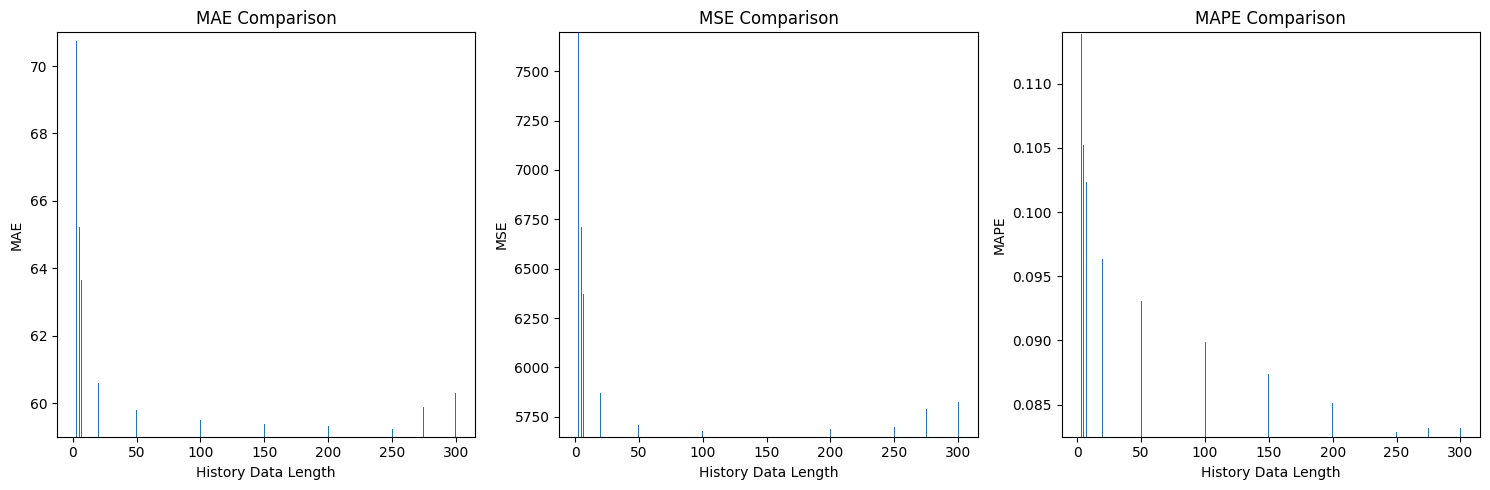

In [ ]:
import matplotlib.pyplot as plt

mae_values = WMA_MAE_list
mse_values = WMA_MSE_list
mape_values = WMA_MAPE_list
x_labels = [3,5,7,20,50,100,150,200,250,275,300]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE plot
axes[0].bar(x_labels, mae_values)
axes[0].set_ylim(int(min(mae_values)), int(max(mae_values)) + 1)
axes[0].set_xlabel('History Data Length')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE Comparison')

# MSE plot
axes[1].bar(x_labels, mse_values)
axes[1].set_ylim(int(min(mse_values)), int(max(mse_values)) + 1)
axes[1].set_xlabel('History Data Length')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison')

# MAPE plot
axes[2].bar(x_labels, mape_values)
axes[2].set_ylim(0.0825, 0.114)
axes[2].set_xlabel('History Data Length')
axes[2].set_ylabel('MAPE')
axes[2].set_title('MAPE Comparison')

plt.tight_layout()
plt.savefig('WMA_tuning.png')
plt.show()


Chosen len_his ∈ [200,250], further tuning:

In [ ]:
WMA_MAE_list=[]
WMA_MSE_list=[]
WMA_MAPE_list=[]
for len_his in [200,212,225,237,250]:
  print(f'Length of history data: {len_his}.')
  len_future = len(demand_data) - len_his
  Forecast.WeightedMovingAverage(len_his)
  MAE = Forecast.get_MAE(len_future)
  MSE = Forecast.get_MSE(len_future)
  MAPE = Forecast.get_MAPE(len_future)
  WMA_MAE_list.append(MAE)
  WMA_MSE_list.append(MSE)
  WMA_MAPE_list.append(MAPE)
  print(f'Mean Absolute Error: {MAE:.4f}.')
  print(f'Mean Squared Error: {MSE:.4f}.')
  print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')
# forecast_results=Forecast.result_df()

Length of history data: 200.
Mean Absolute Error: 59.3177.
Mean Squared Error: 5687.8966.
Mean Absolute Percentage Error: 0.0851.

Length of history data: 212.
Mean Absolute Error: 59.1516.
Mean Squared Error: 5666.6205.
Mean Absolute Percentage Error: 0.0845.

Length of history data: 225.
Mean Absolute Error: 59.2489.
Mean Squared Error: 5686.3390.
Mean Absolute Percentage Error: 0.0840.

Length of history data: 237.
Mean Absolute Error: 59.3784.
Mean Squared Error: 5699.2468.
Mean Absolute Percentage Error: 0.0837.

Length of history data: 250.
Mean Absolute Error: 59.2277.
Mean Squared Error: 5695.8690.
Mean Absolute Percentage Error: 0.0829.



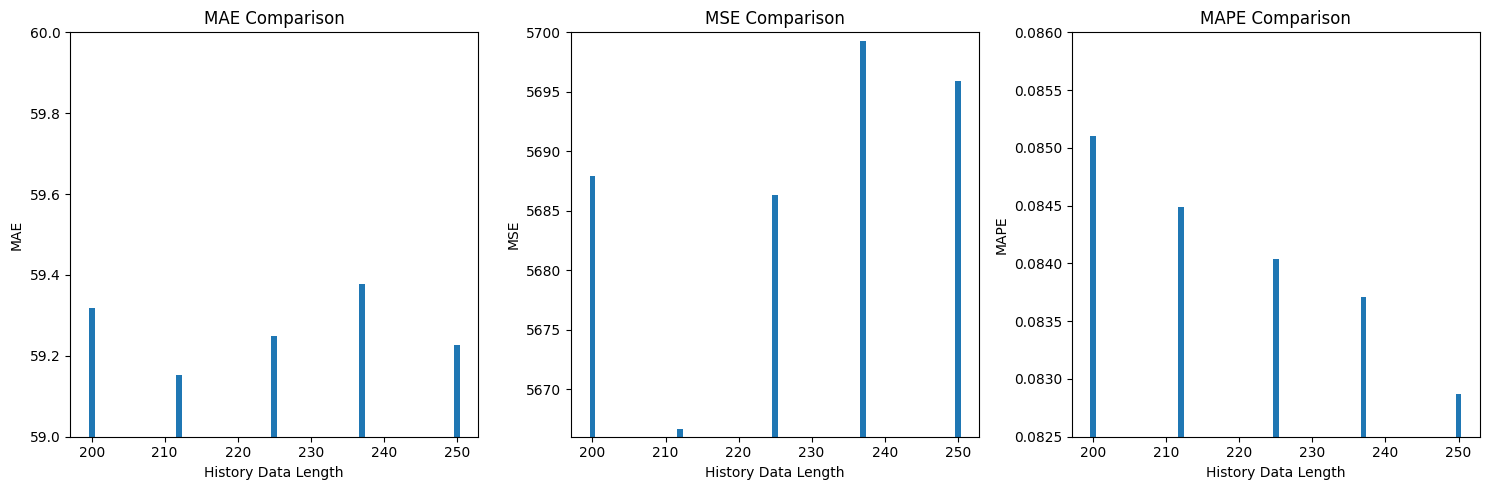

In [ ]:
mae_values = WMA_MAE_list
mse_values = WMA_MSE_list
mape_values = WMA_MAPE_list
x_labels = [200,212,225,237,250]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE plot
axes[0].bar(x_labels, mae_values)
axes[0].set_ylim(int(min(mae_values)), int(max(mae_values)) + 1)
axes[0].set_xlabel('History Data Length')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE Comparison')

# MSE plot
axes[1].bar(x_labels, mse_values)
axes[1].set_ylim(int(min(mse_values)), int(max(mse_values)) + 1)
axes[1].set_xlabel('History Data Length')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison')

# MAPE plot
axes[2].bar(x_labels, mape_values)
axes[2].set_ylim(0.0825, 0.0860)
axes[2].set_xlabel('History Data Length')
axes[2].set_ylabel('MAPE')
axes[2].set_title('MAPE Comparison')

plt.tight_layout()
plt.savefig('WMA_further_tuning.png')
plt.show()


Final tuning: [210,211,212,213,214]

In [ ]:
WMA_MAE_list=[]
WMA_MSE_list=[]
WMA_MAPE_list=[]
for len_his in [210,211,212,213,214]:
  print(f'Length of history data: {len_his}.')
  len_future = len(demand_data) - len_his
  Forecast.WeightedMovingAverage(len_his)
  # Forecast.SimpleMovingAverage(len_his)
  # Forecast.ExponentialSmoothing(0.5)
  # Forecast.DoubleExponentialSmoothing(0.2,0.1)
  # print(f'\nTrue demand: {Forecast.true_demand_data}.')
  # print(f'Forecast results: {Forecast.forecast_list}.')
  MAE = Forecast.get_MAE(len_future)
  MSE = Forecast.get_MSE(len_future)
  MAPE = Forecast.get_MAPE(len_future)
  WMA_MAE_list.append(MAE)
  WMA_MSE_list.append(MSE)
  WMA_MAPE_list.append(MAPE)
  print(f'Mean Absolute Error: {MAE:.4f}.')
  print(f'Mean Squared Error: {MSE:.4f}.')
  print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')
# forecast_results=Forecast.result_df()

Length of history data: 210.
Mean Absolute Error: 59.2406.
Mean Squared Error: 5681.4610.
Mean Absolute Percentage Error: 0.0847.

Length of history data: 211.
Mean Absolute Error: 59.2645.
Mean Squared Error: 5686.1654.
Mean Absolute Percentage Error: 0.0847.

Length of history data: 212.
Mean Absolute Error: 59.1516.
Mean Squared Error: 5666.6205.
Mean Absolute Percentage Error: 0.0845.

Length of history data: 213.
Mean Absolute Error: 59.0189.
Mean Squared Error: 5644.1782.
Mean Absolute Percentage Error: 0.0841.

Length of history data: 214.
Mean Absolute Error: 59.0514.
Mean Squared Error: 5649.5808.
Mean Absolute Percentage Error: 0.0841.



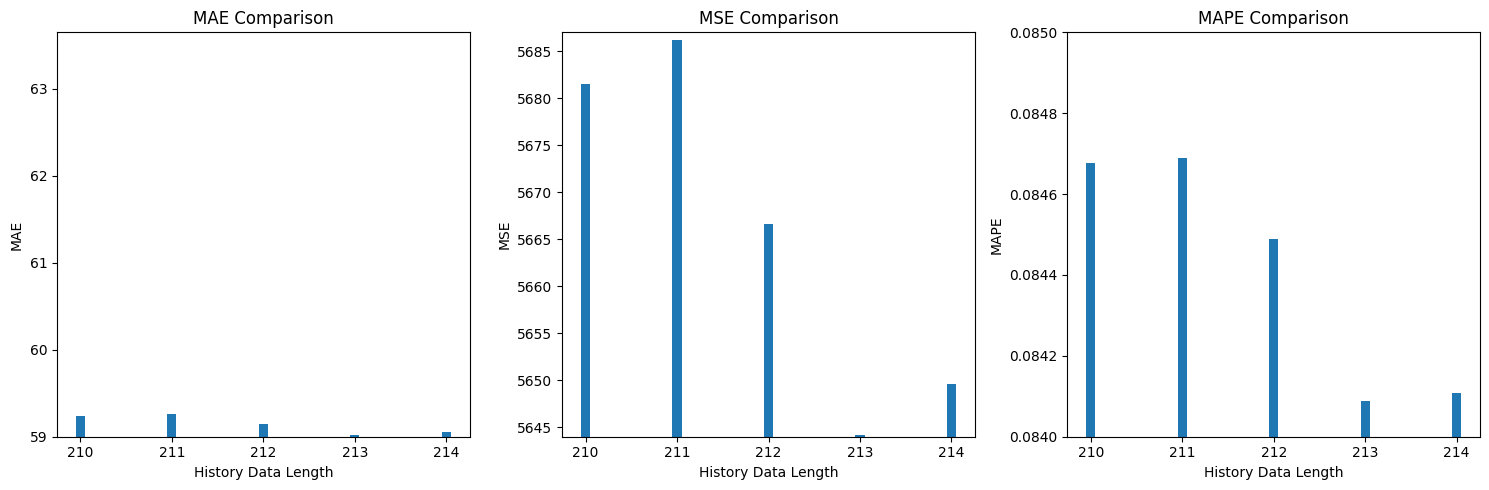

In [ ]:
mae_values = WMA_MAE_list
mse_values = WMA_MSE_list
mape_values = WMA_MAPE_list
x_labels = [210,211,212,213,214]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE plot
axes[0].bar(x_labels, mae_values,width=0.1)
axes[0].set_ylim(int(min(mae_values)), 63.65)
axes[0].set_xlabel('History Data Length')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE Comparison')

# MSE plot
axes[1].bar(x_labels, mse_values,width=0.1)
axes[1].set_ylim(int(min(mse_values)), int(max(mse_values)) + 1)
axes[1].set_xlabel('History Data Length')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison')

# MAPE plot
axes[2].bar(x_labels, mape_values,width=0.1)
axes[2].set_ylim(0.0840, 0.0850)
axes[2].set_xlabel('History Data Length')
axes[2].set_ylabel('MAPE')
axes[2].set_title('MAPE Comparison')

plt.tight_layout()
plt.savefig('WMA_final_tuning.png')
plt.show()


**Inconsistent results with Excel optimization solver at window=50**

In [ ]:
len_his = 50
print(f'Length of history data: {len_his}.')
len_future = len(demand_data) - len_his
Forecast.WeightedMovingAverage(len_his)
MAE = Forecast.get_MAE(len_future)
MSE = Forecast.get_MSE(len_future)
MAPE = Forecast.get_MAPE(len_future)

print(f'Mean Absolute Error: {MAE:.4f}.')
print(f'Mean Squared Error: {MSE:.4f}.')
print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')
forecast_results=Forecast.result_df()

Length of history data: 50.
Mean Absolute Error: 59.7803.
Mean Squared Error: 5706.3727.
Mean Absolute Percentage Error: 0.0931.



In [ ]:
weights_df=DataFrame({'weight':Forecast.weights})
weights_df.to_csv('weights_window50.csv',index=False)

**Finally Chosen Length of Historical Data: window=213**

In [ ]:
len_his = 213
print(f'Length of history data: {len_his}.')
len_future = len(demand_data) - len_his
Forecast.WeightedMovingAverage(len_his)
MAE = Forecast.get_MAE(len_future)
MSE = Forecast.get_MSE(len_future)
MAPE = Forecast.get_MAPE(len_future)

print(f'Mean Absolute Error: {MAE:.4f}.')
print(f'Mean Squared Error: {MSE:.4f}.')
print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')
forecast_results=Forecast.result_df()

Length of history data: 213.
Mean Absolute Error: 59.0189.
Mean Squared Error: 5644.1782.
Mean Absolute Percentage Error: 0.0841.



In [ ]:
import numpy as np
from IPython.display import display
weights=np.array(Forecast.weights)
display(np.where(weights>1e-3))
display(np.sum(weights[weights>1e-3]))
display(len(weights[86:]))

(array([ 86, 130, 134, 135, 140, 147, 149, 155, 157, 163, 167, 175, 180,
        183, 184, 186, 187, 188, 191, 192, 193, 194, 195, 196, 197, 199,
        200, 202, 203, 204, 206, 207, 208, 209, 210, 212]),)

np.float64(0.999080863603319)

127

In [ ]:
weights_df=DataFrame({'weight':weights})
weights_df.to_csv('weights.csv',index=False)

In [ ]:
forecast = forecast_results.drop(columns=['Demand'])
forecast.index = forecast_results.index +1
forecast.index.name = 'Day'
forecast.to_csv('Forecast Results.csv', index=True)

## 5.DES Tuning hyperparam: alpha, beta


In [27]:
DES_MAE_list={}
DES_MSE_list={}
DES_MAPE_list={}
for alpha in [0.1,0.4,0.7,0.8,0.9]:
  DES_MAE_list[alpha]=[]
  DES_MSE_list[alpha]=[]
  DES_MAPE_list[alpha]=[]
  print(f'Alpha: {alpha}.')
  for beta in [0.1,0.3,0.5,0.7,0.9]:
    print(f'Beta: {beta}.')
    Forecast.MultiStepDoubleExponentialSmoothing(alpha,beta,5,0.8)
    MAE = Forecast.get_MAE(len(demand_data))
    MSE = Forecast.get_MSE(len(demand_data))
    MAPE = Forecast.get_MAPE(len(demand_data))
    DES_MAE_list[alpha].append(MAE)
    DES_MSE_list[alpha].append(MSE)
    DES_MAPE_list[alpha].append(MAPE)
    print(f'Mean Absolute Error: {MAE:.4f}.')
    print(f'Mean Squared Error: {MSE:.4f}.')
    print(f'Mean Absolute Percentage Error: {MAPE:.4f}.\n')
  print('---------------------------------------------------------------------------------------------------------------------\n')

Alpha: 0.1.
Beta: 0.1.
Mean Absolute Error: 66.0894.
Mean Squared Error: 6796.4517.
Mean Absolute Percentage Error: 0.1051.

Beta: 0.3.
Mean Absolute Error: 71.1055.
Mean Squared Error: 7984.0002.
Mean Absolute Percentage Error: 0.1125.

Beta: 0.5.
Mean Absolute Error: 78.0540.
Mean Squared Error: 9511.3262.
Mean Absolute Percentage Error: 0.1239.

Beta: 0.7.
Mean Absolute Error: 94.4833.
Mean Squared Error: 14389.6964.
Mean Absolute Percentage Error: 0.1473.

Beta: 0.9.
Mean Absolute Error: 178.0953.
Mean Squared Error: 48030.0597.
Mean Absolute Percentage Error: 0.2663.

---------------------------------------------------------------------------------------------------------------------

Alpha: 0.4.
Beta: 0.1.
Mean Absolute Error: 70.9371.
Mean Squared Error: 7774.6589.
Mean Absolute Percentage Error: 0.1134.

Beta: 0.3.
Mean Absolute Error: 76.6281.
Mean Squared Error: 9118.6880.
Mean Absolute Percentage Error: 0.1216.

Beta: 0.5.
Mean Absolute Error: 89.4703.
Mean Squared Error: 13

In [53]:
import matplotlib.pyplot as plt

def plotDES(alpha,beta_list):
  mae_values = DES_MAE_list[alpha]
  mse_values = DES_MSE_list[alpha]
  mape_values = DES_MAPE_list[alpha]
  x_labels = beta_list

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))

  # MAE plot
  axes[0].plot(x_labels, mae_values, c = 'red')
  axes[0].set_ylim(int(min(mae_values)), int(max(mae_values)) + 1)
  axes[0].set_xlabel('Beta')
  axes[0].set_ylabel('MAE')
  axes[0].set_title(f'MAE Comparison at alpha = {alpha}')

  # MSE plot
  axes[1].plot(x_labels, mse_values, c = 'blue')
  axes[1].set_ylim(int(min(mse_values)), int(max(mse_values)) + 1)
  axes[1].set_xlabel('Beta')
  axes[1].set_ylabel('MSE')
  axes[1].set_title(f'MSE Comparison at alpha = {alpha}')

  # MAPE plot
  axes[2].plot(x_labels, mape_values, c = 'purple')
  axes[2].set_ylim(min(mape_values), max(mape_values))
  axes[2].set_xlabel('Beta')
  axes[2].set_ylabel('MAPE')
  axes[2].set_title(f'MAPE Comparison at alpha = {alpha}')

  plt.tight_layout()
  plt.savefig(f'DES_alpha_{alpha}.png')
  plt.show()


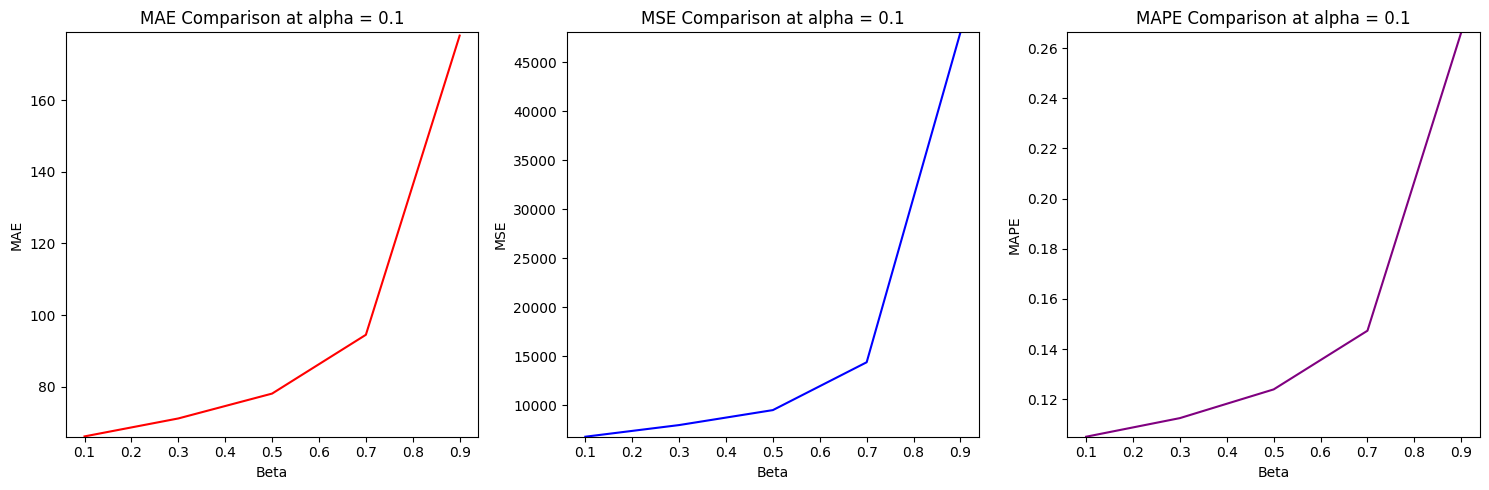

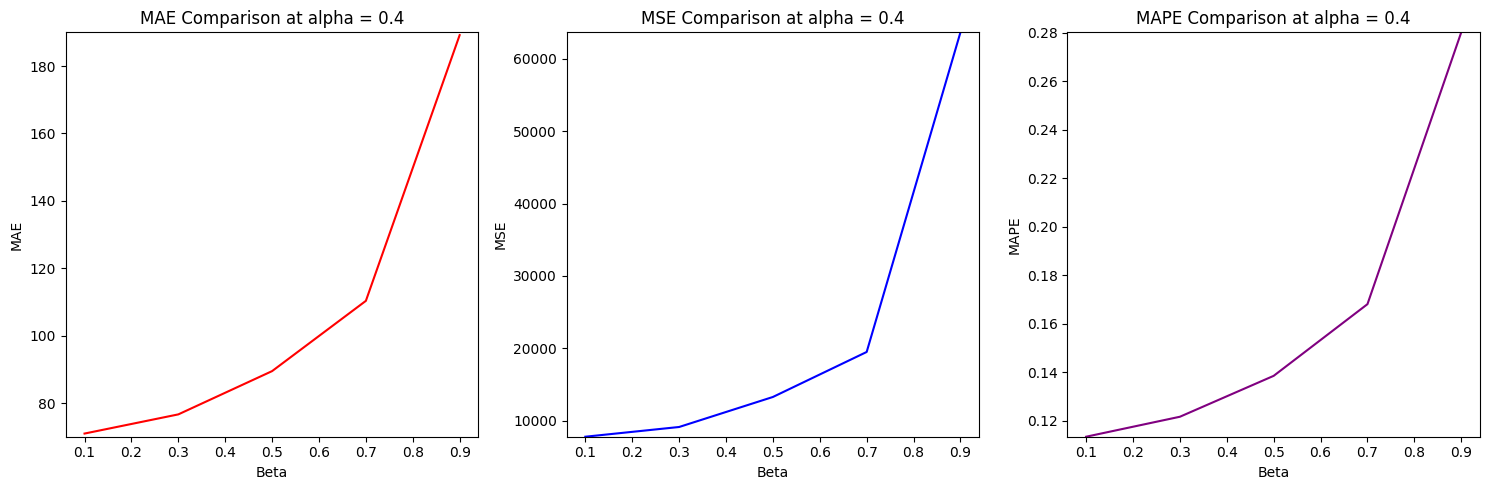

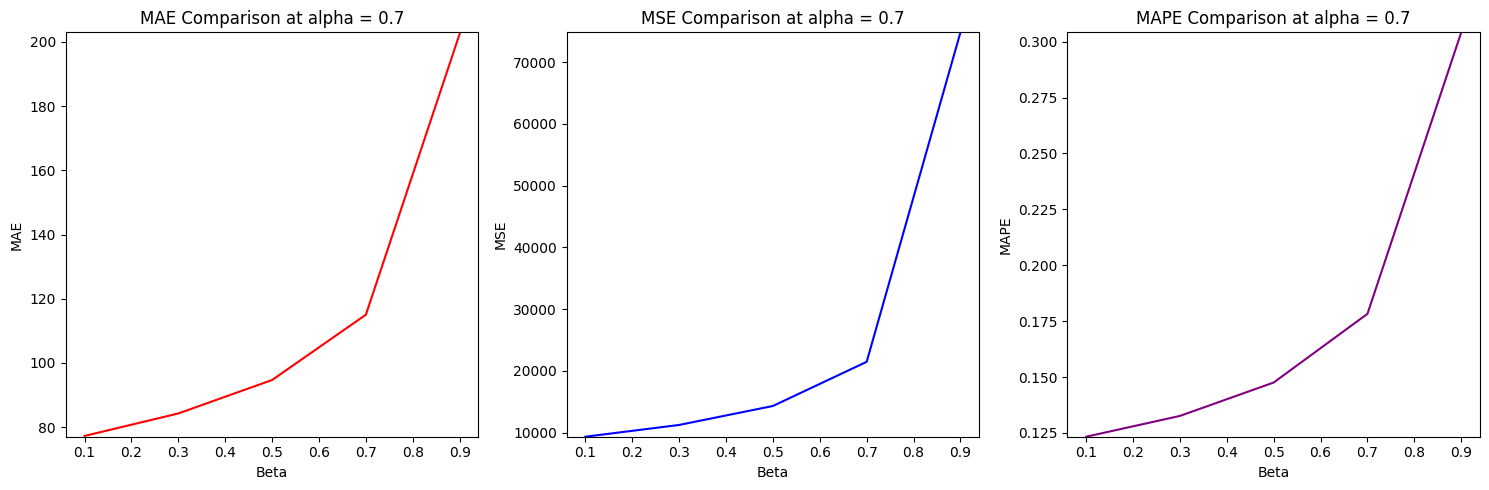

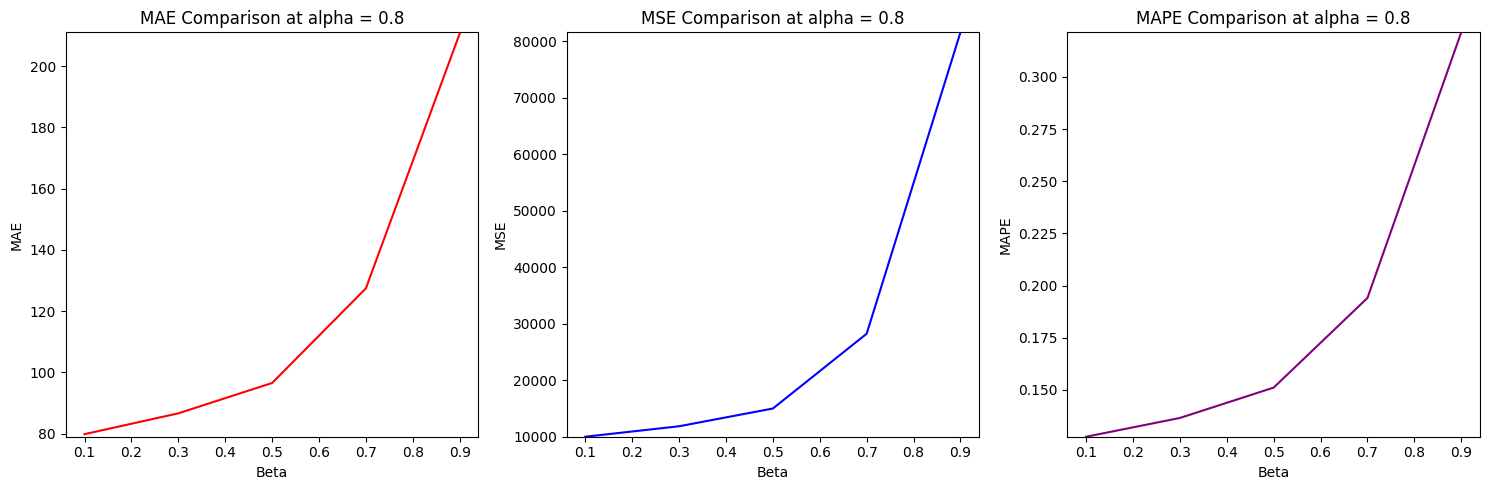

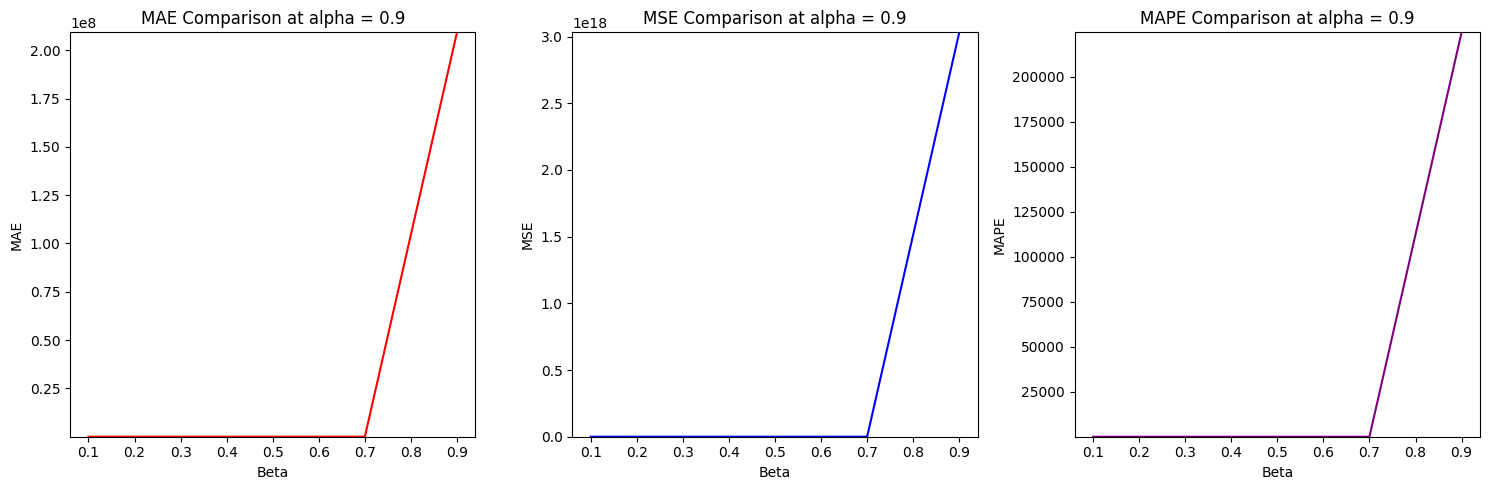

In [54]:
for alpha in [0.1,0.4,0.7,0.8,0.9]:
  plotDES(alpha,[0.1,0.3,0.5,0.7,0.9])

## 6.Forecast Results Visualisation

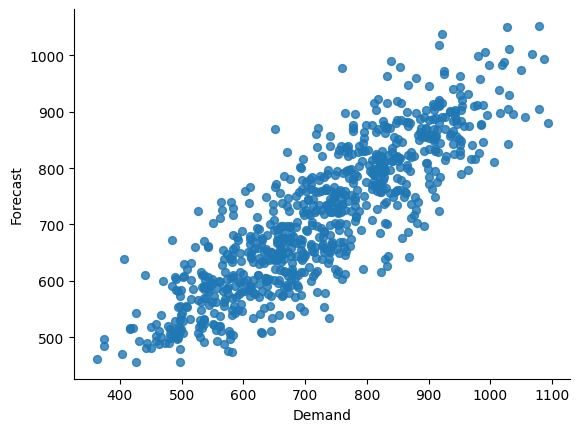

In [ ]:
from matplotlib import pyplot as plt
forecast_results[len_his:].plot(kind='scatter', x='Demand', y='Forecast', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.savefig('WMA_Forecast_Results.png')

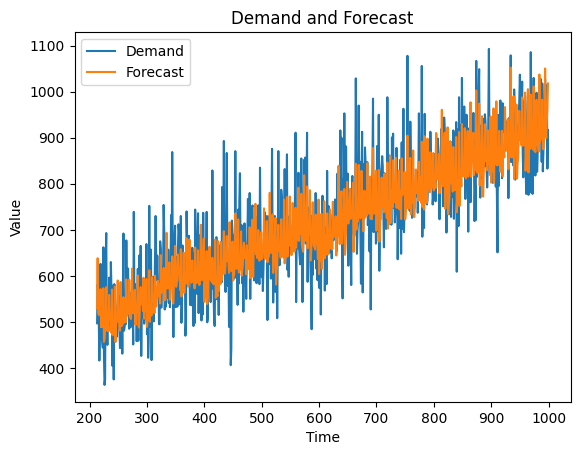

In [ ]:
plt.plot(forecast_results[len_his:]['Demand'], label='Demand')
plt.plot(forecast_results[len_his:]['Forecast'], label='Forecast')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Demand and Forecast')

plt.legend()
plt.savefig('WMA_Forecast_Results_line.png')
plt.show()
